<a href="https://colab.research.google.com/github/kaviya2478/100_days_ML/blob/main/Bitcoin_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Executive Summary**

This project analyzes the relationship between Bitcoin market sentiment and trader performance using Hyperliquid historical trading data combined with the Fear & Greed Index.

The objective was to identify how emotional market conditions influence:

trader profitability

win rates

trading volume

coin-specific performance

overall trading behavior

Using Python-based exploratory data analysis and visualization, the project uncovered strong sentiment-driven behavioral patterns and trading opportunities.

**Objective**

To explore the relationship between cryptocurrency market sentiment and trader performance by integrating:

Fear & Greed Index data

Hyperliquid trading activity

and identifying actionable trading insights.

**Datasets Used**

**1. Bitcoin Fear & Greed Index  **

**Contains:**

market sentiment

classification

sentiment score

date

**2. Hyperliquid Historical Trader Data**

**Contains:**

account activity

execution prices

position sizes

trade direction

PnL

trading volume

fees

**Methodology**

Cleaned and transformed datasets

Standardized timestamps

Merged datasets on common dates

Performed exploratory data analysis

**Conducted:**

sentiment profitability analysis

win-rate analysis

trading volume analysis

coin performance analysis

trader leaderboard analysis

time-series profitability analysis

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [10]:
trader_df = pd.read_csv('/content/historical_data.csv')
sentiment_df = pd.read_csv('/content/fear_greed_index.csv')

In [11]:
print(trader_df.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [12]:
print(sentiment_df.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [13]:
# Convert sentiment dataset date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

# Convert trader timestamp
trader_df['Timestamp IST'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

# Create common Date column
trader_df['date'] = trader_df['Timestamp IST'].dt.date

# Convert back to datetime
trader_df['date'] = pd.to_datetime(trader_df['date'])

print("Date conversion completed")

Date conversion completed


In [14]:
merged_df = pd.merge(
    trader_df,
    sentiment_df,
    on='date',
    how='left'
)

print("Merged Successfully")
print(merged_df.head())

Merged Successfully
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Ord

In [15]:
print(merged_df['classification'].isnull().sum())

6


In [16]:
print(merged_df['classification'].value_counts())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


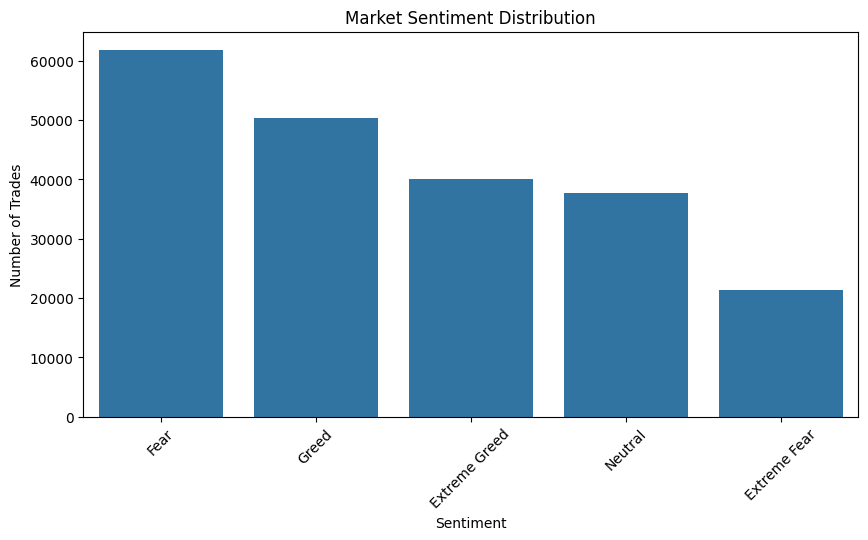

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=merged_df,
    x='classification',
    order=merged_df['classification'].value_counts().index
)

plt.title("Market Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.show()

In [18]:
sentiment_pnl = merged_df.groupby(
    'classification'
)['Closed PnL'].mean().sort_values(ascending=False)

print(sentiment_pnl)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


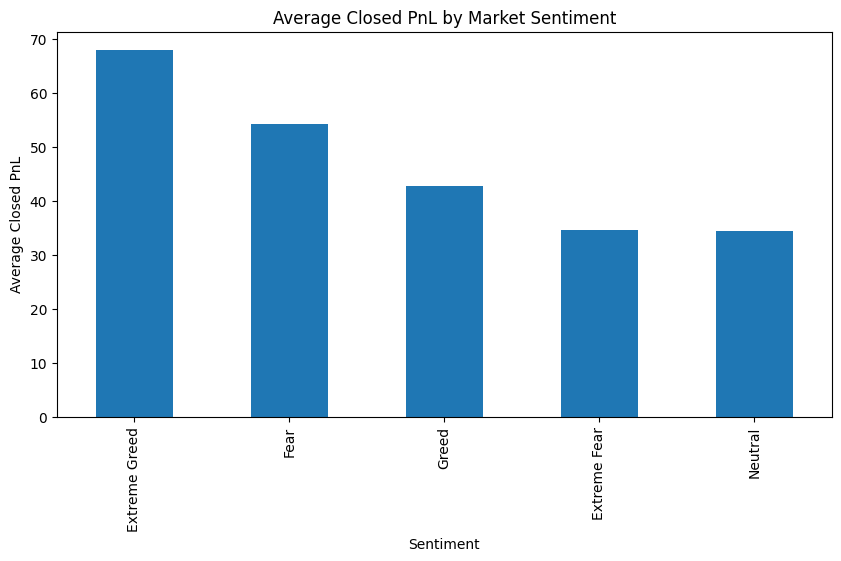

In [19]:
plt.figure(figsize=(10,5))

sentiment_pnl.plot(kind='bar')

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

In [22]:
merged_df['is_profit'] = merged_df['Closed PnL'] > 0

In [23]:
win_rate = merged_df.groupby(
    'classification'
)['is_profit'].mean()

print(win_rate)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: is_profit, dtype: float64


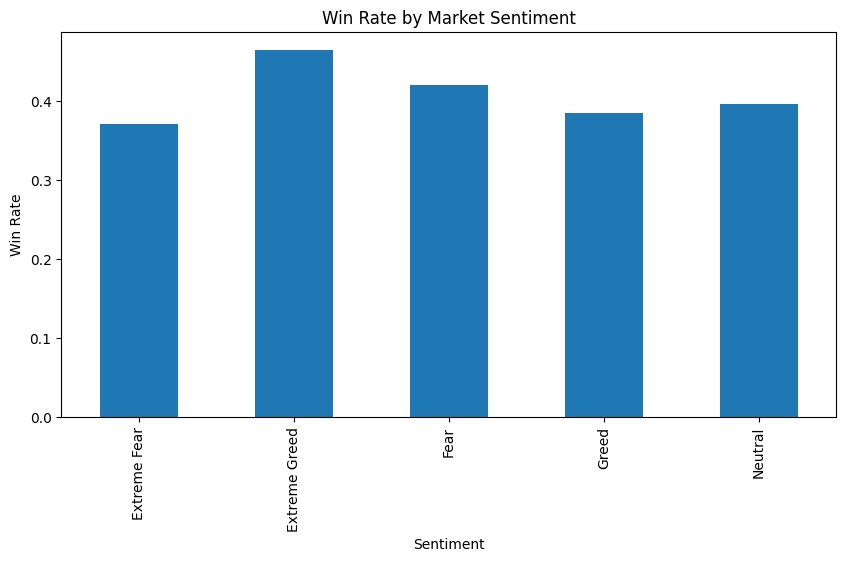

In [24]:
plt.figure(figsize=(10,5))

win_rate.plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")

plt.show()

In [25]:
volume_analysis = merged_df.groupby(
    'classification'
)['Size USD'].sum()

print(volume_analysis)

classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64


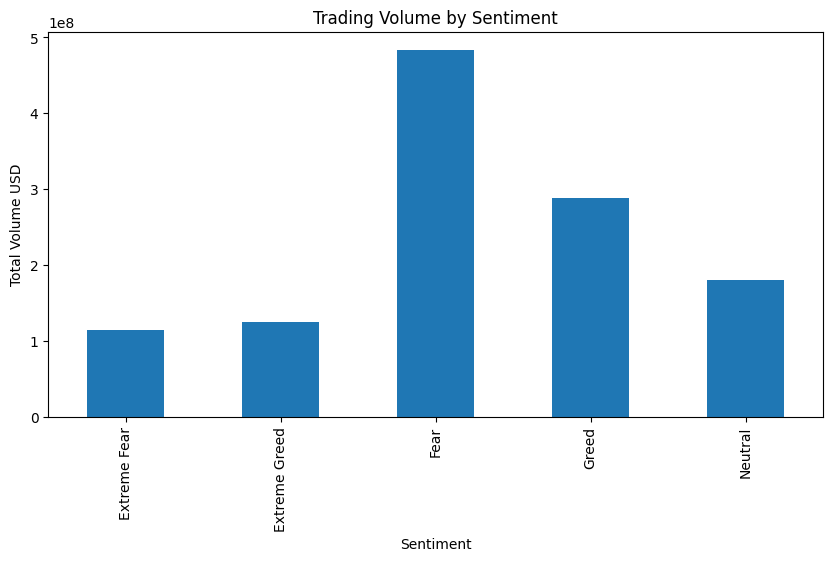

In [26]:
plt.figure(figsize=(10,5))

volume_analysis.plot(kind='bar')

plt.title("Trading Volume by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Total Volume USD")

plt.show()

In [27]:
symbol_pnl = merged_df.groupby(
    ['classification', 'Coin']
)['Closed PnL'].mean().reset_index()

print(symbol_pnl.head(20))

   classification  Coin  Closed PnL
0    Extreme Fear   @10   -0.031742
1    Extreme Fear  @107  -89.588788
2    Extreme Fear   @13   -0.061895
3    Extreme Fear  @142   15.529335
4    Extreme Fear   @16   -0.030214
5    Extreme Fear   @26   -0.032252
6    Extreme Fear   @29   -0.019593
7    Extreme Fear   @35   33.514063
8    Extreme Fear   @38   33.271993
9    Extreme Fear   @39   12.238556
10   Extreme Fear    @4  -13.810710
11   Extreme Fear   @40   16.748319
12   Extreme Fear   @41   36.738440
13   Extreme Fear   @47   25.156729
14   Extreme Fear   @49  -10.178054
15   Extreme Fear   @51    0.000000
16   Extreme Fear    @8    1.432312
17   Extreme Fear  AAVE    0.000000
18   Extreme Fear   ADA -182.081319
19   Extreme Fear    AI    0.000000


In [28]:
top_traders = merged_df.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(ascending=False)

print(top_traders.head(10))

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


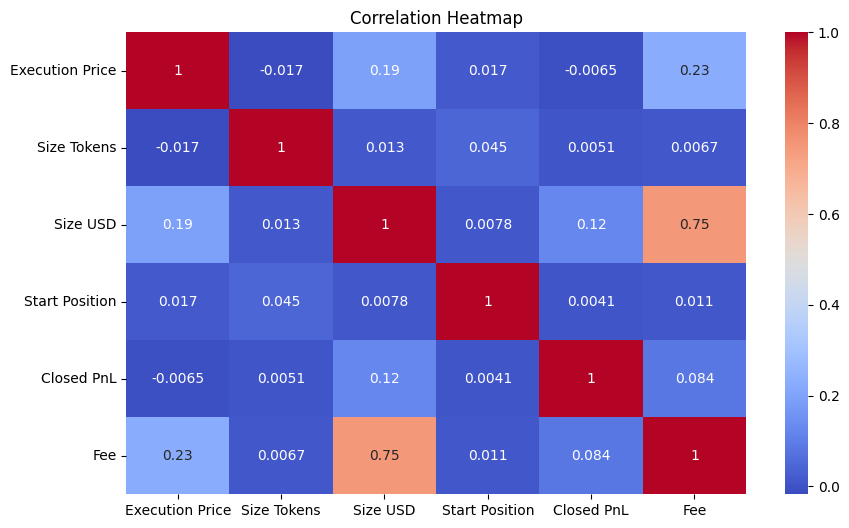

In [29]:
numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Start Position',
    'Closed PnL',
    'Fee'
]

correlation = merged_df[numeric_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [30]:
top_traders = merged_df.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(ascending=False)

print(top_traders.head(10))

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


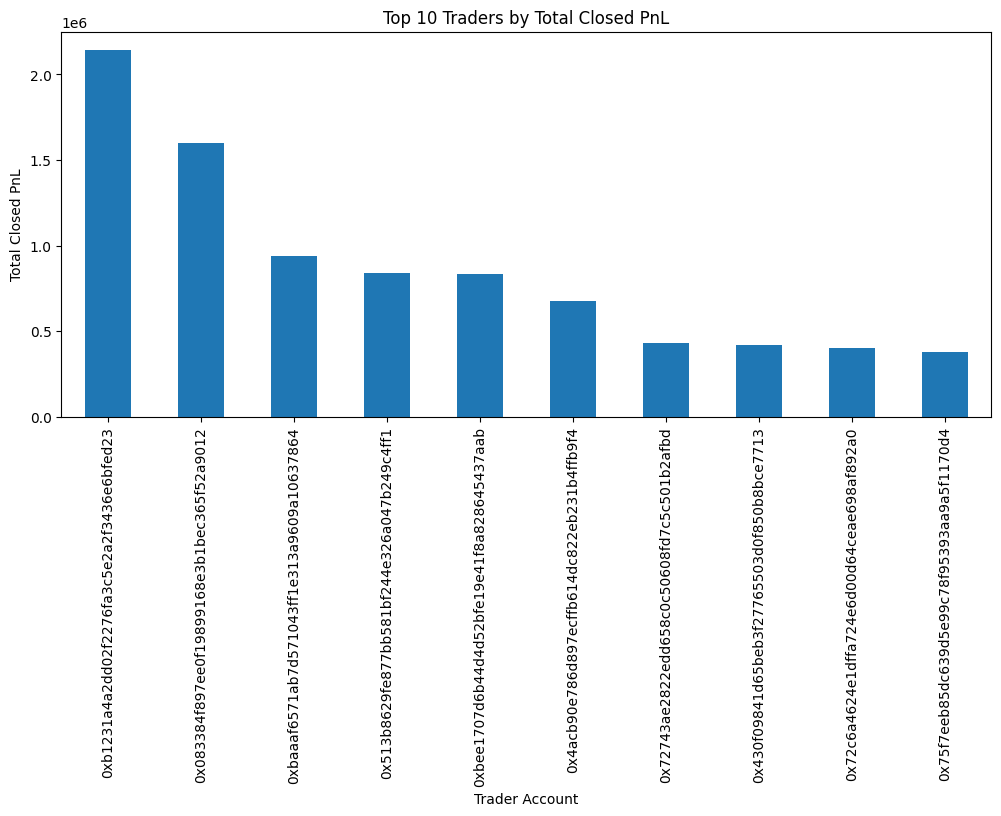

In [31]:
plt.figure(figsize=(12,5))

top_traders.head(10).plot(kind='bar')

plt.title("Top 10 Traders by Total Closed PnL")
plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL")

plt.show()

In [32]:
coin_pnl = merged_df.groupby(
    'Coin'
)['Closed PnL'].mean().sort_values(ascending=False)

print(coin_pnl.head(10))

Coin
@109       270.704207
AVAX       239.095613
ENA        219.524751
@85        200.804091
EIGEN      197.063189
PEOPLE     180.323003
DOGE       178.623676
SOL        153.358519
MOODENG    151.096714
ZRO        148.327509
Name: Closed PnL, dtype: float64


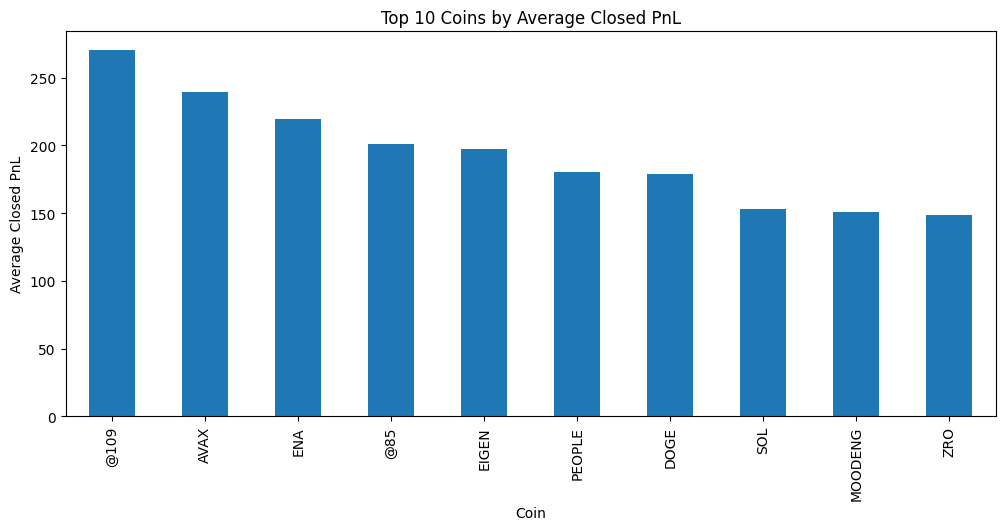

In [33]:
plt.figure(figsize=(12,5))

coin_pnl.head(10).plot(kind='bar')

plt.title("Top 10 Coins by Average Closed PnL")
plt.xlabel("Coin")
plt.ylabel("Average Closed PnL")

plt.show()

In [34]:
coin_sentiment = merged_df.groupby(
    ['classification', 'Coin']
)['Closed PnL'].mean().reset_index()

print(coin_sentiment.head(20))

   classification  Coin  Closed PnL
0    Extreme Fear   @10   -0.031742
1    Extreme Fear  @107  -89.588788
2    Extreme Fear   @13   -0.061895
3    Extreme Fear  @142   15.529335
4    Extreme Fear   @16   -0.030214
5    Extreme Fear   @26   -0.032252
6    Extreme Fear   @29   -0.019593
7    Extreme Fear   @35   33.514063
8    Extreme Fear   @38   33.271993
9    Extreme Fear   @39   12.238556
10   Extreme Fear    @4  -13.810710
11   Extreme Fear   @40   16.748319
12   Extreme Fear   @41   36.738440
13   Extreme Fear   @47   25.156729
14   Extreme Fear   @49  -10.178054
15   Extreme Fear   @51    0.000000
16   Extreme Fear    @8    1.432312
17   Extreme Fear  AAVE    0.000000
18   Extreme Fear   ADA -182.081319
19   Extreme Fear    AI    0.000000


In [35]:
best_coins = coin_sentiment.loc[
    coin_sentiment.groupby('classification')['Closed PnL'].idxmax()
]

print(best_coins)

    classification    Coin   Closed PnL
60    Extreme Fear    PNUT  1855.649224
202  Extreme Greed  PEOPLE   360.646005
360           Fear     SEI   835.600000
388          Greed    @109   416.218936
624        Neutral    DOGE  2969.473495


In [36]:
daily_pnl = merged_df.groupby(
    'date'
)['Closed PnL'].sum()

print(daily_pnl.head())

date
2023-05-01      0.000000
2023-12-05      0.000000
2023-12-14   -205.434737
2023-12-15    -24.632034
2023-12-16      0.000000
Name: Closed PnL, dtype: float64


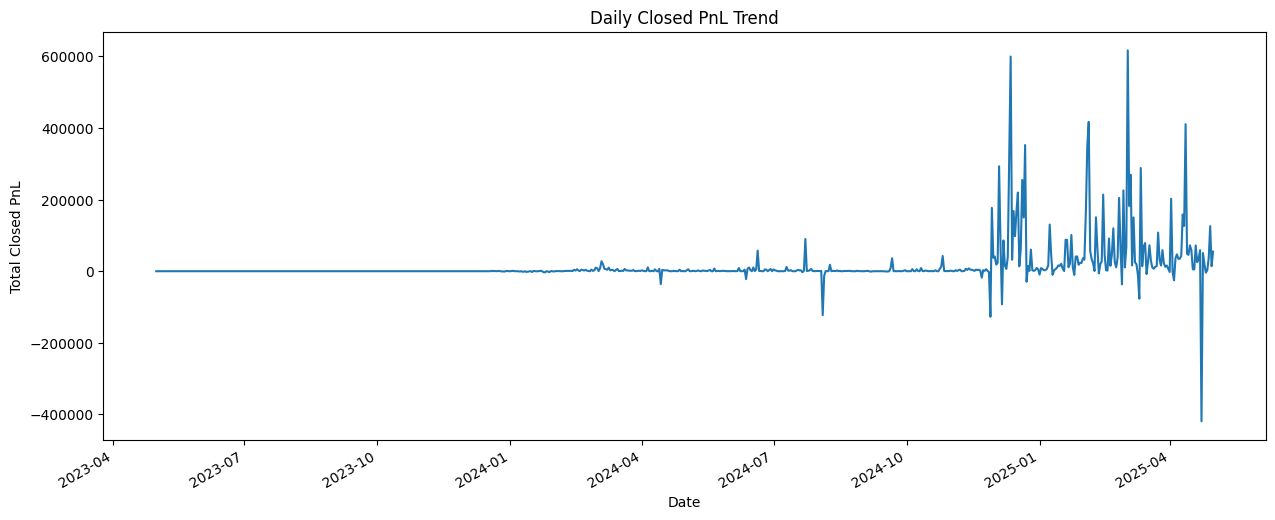

In [37]:
plt.figure(figsize=(15,6))

daily_pnl.plot()

plt.title("Daily Closed PnL Trend")
plt.xlabel("Date")
plt.ylabel("Total Closed PnL")

plt.show()

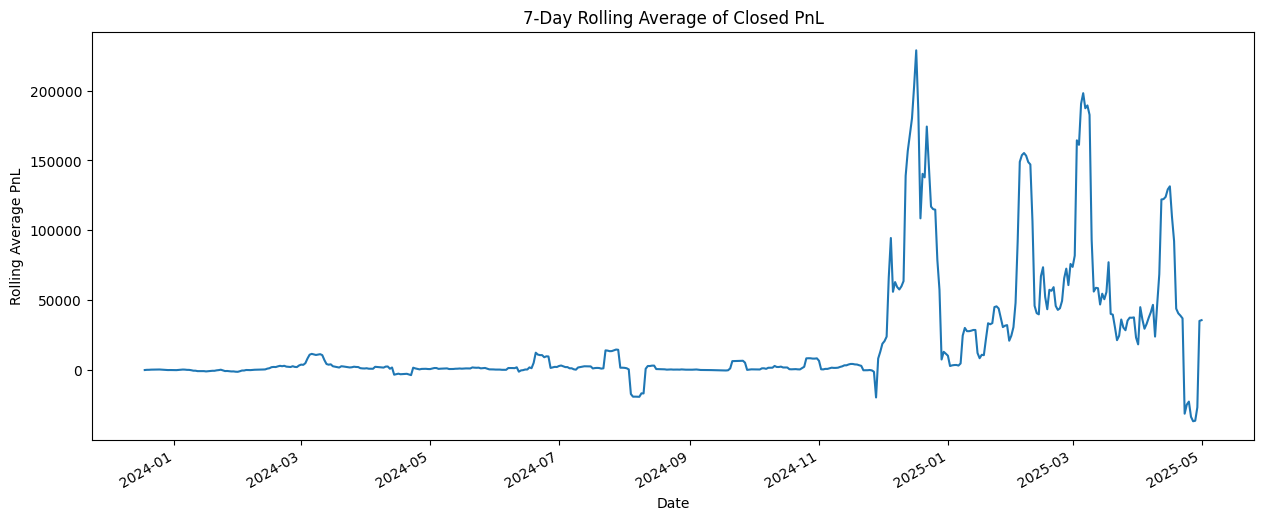

In [38]:
rolling_pnl = daily_pnl.rolling(window=7).mean()

plt.figure(figsize=(15,6))

rolling_pnl.plot()

plt.title("7-Day Rolling Average of Closed PnL")
plt.xlabel("Date")
plt.ylabel("Rolling Average PnL")

plt.show()

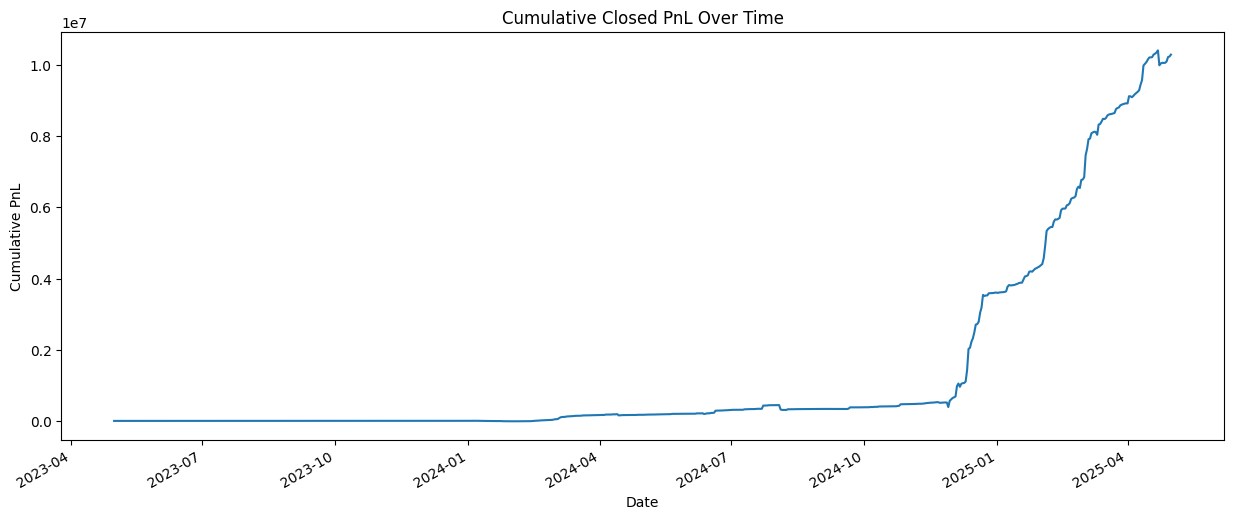

In [39]:
cumulative_pnl = daily_pnl.cumsum()

plt.figure(figsize=(15,6))

cumulative_pnl.plot()

plt.title("Cumulative Closed PnL Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL")

plt.show()

**Key Findings**
1. Extreme Greed Produced Highest Profitability

Highest average Closed PnL

Highest trader win rate

Momentum strategies performed strongly

2. Fear Markets Created Contrarian Opportunities

Traders achieved strong profitability during Fear conditions

Suggests successful dip-buying behavior

3. Extreme Fear Triggered Emotional Trading

Trading volume spiked dramatically

Win rate declined significantly

Indicates panic-driven trading activity

4. Profitability Was Concentrated Among Few Traders

Top traders dominated total PnL

Suggests institutional or highly disciplined strategies outperform retail behavior

5. Asset Performance Varied by Sentiment


Different coins outperformed under different emotional market conditions.

**Examples:**

PNUT during Extreme Fear

PEOPLE during Extreme Greed

SEI during Fear

**Trading Strategy Recommendations**

Trend Following During Extreme Greed

Use:

momentum strategies

breakout trading

trailing stop-loss systems

Contrarian Accumulation During Fear

Gradually accumulate strong assets during fearful market conditions.

Risk Reduction During Extreme Fear

Reduce:

leverage

position size

overtrading behavior

Sentiment-Aware Asset Selection

Different coins perform better under different emotional market conditions.

**Conclusion**

The analysis demonstrates that cryptocurrency market sentiment significantly impacts:

trader profitability

trading behavior

market participation

asset performance

Sentiment-aware trading strategies may improve risk management and profitability by adapting to changing emotional market conditions.